## EEE205 Artificial Intelligence I
# Part 13 - Classification
## Tutorial
### Barry Dillon

**1 - In your own words, write down a definition of each of these concepts.**

Look at the terms below and try to explain what they are and why they are used.  First from memory, without checking notes or the internet.  Then check your notes/internet to improve what you have.  This is a good learning technique.

1- The Sigmoid function

- A mathematical curve, maps any real number to a value between 0 and 1
- Used to turn a model’s raw score into a probability for the positive class
   
Graph is horizontal at the x-axis at (-14.51, 0)
(14.51, 1) in the first quadrant
y-intercept is (0, 0.5)

f(x) = 1/(1 + e^-z)

- For binary classification

2 - The Softmax function

- Used when there are more than 2 classes
- Takes a list of scores (vector of raw scores, logits), and converts them into a probability distribution over classes.

3 - Binary vs multi-class classification

4 - Decision boundary

5 - Accuracy

**2 - Binary classification with the Iris dataset using logistic regression**

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [20]:
# Load the iris dataset
iris = load_iris()

# Features and target
X = iris.data  # shape (150, 4) (rows,columns), 2D 
y = iris.target  # shape (150,)  1D, y is the label vector 0  -> Setosa
#                                                          1  -> Versicolor
#                                                          2  -> Virginica

print('Feature names:', iris.feature_names)   #input features
print('Target names:', iris.target_names)    #names of flower species
print('X shape:', X.shape)
print('y shape:', y.shape)   #sizes of x and y


Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']
X shape: (150, 4)
y shape: (150,)


In [21]:
df = pd.DataFrame(X, columns=iris.feature_names) #turns data into dataframe for easier viewing
#coverts numpy array x into a pandas.DataFrame namde df.
df['species'] = y           


1 - Do a basic exploration of the dataset using pandas.

In [22]:
df.sample(5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
143,6.8,3.2,5.9,2.3,2
124,6.7,3.3,5.7,2.1,2
125,7.2,3.2,6.0,1.8,2
53,5.5,2.3,4.0,1.3,1
32,5.2,4.1,1.5,0.1,0


2 - The code below creates masks that index only the Setosa and Versicolor classes.  Comment the code and explain what is happening.

In [23]:
# masks to select only setosa and versicolor
mask_setosa = ( y==0 ) #y is 1D numpy array e.g.[0,0,1,1,2..]
mask_versicolor = (y==1 )
mask_twoclass = mask_setosa | mask_versicolor # | means OR
# only true for setosa OR versicolor, this mask keeps only first 2 classes, making this 
# a binary classification problem

3 - Finish the code below to make a scatter plot of the petal length (x-axis) vs petal width (y-axis) features showing the datapoints belonging to each class separately.  Comment the code to explain what is happening.  Hint:  use the masks, check how to index numpy arrays.

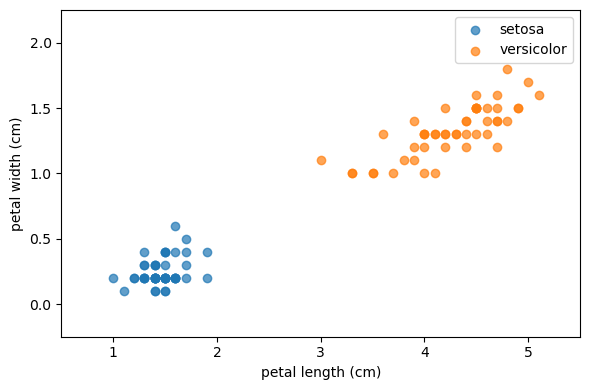

In [24]:
plt.figure(figsize=(6, 4))
# creates new figure (canvas) for plotting with size 6 wide and 4 length

# Plot petal length (feature 2) vs petal width (feature 3) for the two classes

plt.scatter(X[mask_setosa, 2] , X[mask_setosa, 3], label='setosa', alpha=0.7)   
#     x-values petal length      y-values petal width     for  setosa
# X is the array of x-coordinates
#alpha=0.7 transparency of points, reduces overplotting (overlapping points r visible)

plt.scatter(X[mask_versicolor, 2], X[mask_versicolor, 3], label='versicolor', alpha=0.7)
#       x-values petal length      y-values petal width     for  versicolor

# X is the feature matrix, all input measurements of dataset, each column is a feature (sepal length (cm)	sepal width (cm) e.g)
# 


plt.xlabel('petal length (cm)') # adds a label to x-axis
plt.ylabel('petal width (cm)') # adds label to y-axis

plt.ylim(-0.25,2.25)  # sets range of y and x-axis  (ymin, ymax)
plt.xlim(0.5,5.5)
plt.legend()
plt.tight_layout()  # adjusts spacing so labels/titles/legend dont overlap
plt.show()

3 - Use the masks to index the original dataset `X` and it's labels `y`, call the new dataset and labels `X_tc` and `y_tc`, `tc` stands for 'two class'.

In [25]:
X_tc = X[mask_twoclass]
#         Boolean array
#      True if sample is setosa or vericolor, false if virginica
# X[mask] only returns rows where mask == True
# gives only rows with class 0 or 1 (binary-only features)
# y_tc: only labels 0 or 1 Virginica (class 2) is removed.

In [26]:
y_tc = y[mask_twoclass]

4 - Check the shape of the features, now restrict the features to just two, the petal length and petal width.

In [27]:
X_tc.shape

(100, 4)

In [28]:
X_tc = X_tc[:, 2:4]

In [29]:
X_tc.shape  # 100 samples (50 setosa and 50 versicolor), and 2 features (petal length and petal width)

(100, 2)

5 - Create a train/test split with 80/20 in the data.  Name the feature variables `X_train` and `X_test`, and the labels `y_train` and `y_test`.

In [30]:
# 80/20 train–test split for the two-class problem
X_train, X_test, y_train, y_test = train_test_split(
    X_tc, y_tc, test_size=0.2, random_state=0, stratify=y_tc
)

print('X_train shape:', X_train.shape)
print('X_test  shape:', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test  shape:', y_test.shape)


#Output shapes should be:

#  X_train: 80 samples × 2 features

#  X_test: 20 samples × 2 features

#  y_train: 80 labels

#  y_test: 20 labels

X_train shape: (80, 2)
X_test  shape: (20, 2)
y_train shape: (80,)
y_test  shape: (20,)


6 - The code below initialises the model.  Finish the second line to perform the fit:

In [31]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)    # fit on the training data

LogisticRegression(max_iter=1000)

7 - Complete the code below to make predictions for the train and test data.  Hint: use `model.predict()`.

In [32]:
y_train_pred = model.predict(X_train)

In [33]:
y_test_pred = model.predict(X_test)

8 - Complete the code below to compute the accuracies.  Look up the syntax for using the `accuracy_score()` function, it's similar to the mse score and r2 score.

In [34]:
train_acc = accuracy_score(y_train, y_train_pred)    #compute accuracy on the training
test_acc = accuracy_score(y_test, y_test_pred)    # and test sets

print(f'Training accuracy: {train_acc:.3f}')
print(f'Test accuracy:     {test_acc:.3f}')

Training accuracy: 1.000
Test accuracy:     1.000


Is this a good model?

yes, 1 is the most accurate score for accuracy, scatter plot also shows that Setosa and Versicolor form two clearly separated clusters,

the decision boundary lies cleanly between them. Generalises well without overfitting.

Linearly seperable, the two classes can be seperated with a single straight line with no overlap.

The code below computes and plots the decision boundary on top of the scatter plot, to help visualise how the logistic regression classifier that we trained makes its decision.  Read and understand this code carefully.

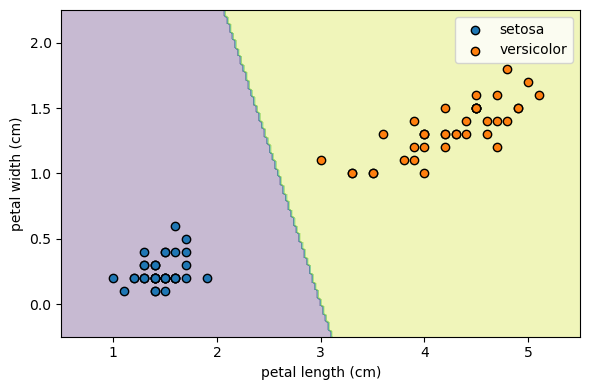

In [35]:
# Create a grid of points covering the feature space
x_min, x_max = X_tc[:, 0].min() - 0.5, X_tc[:, 0].max() + 0.5
y_min, y_max = X_tc[:, 1].min() - 0.5, X_tc[:, 1].max() + 0.5
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# Predict class for each point in the grid
grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(6, 4))

# Plot decision regions
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot training points
mask_setosa = (y_train == 0)
mask_versicolor = (y_train == 1)
plt.scatter(X_train[mask_setosa, 0], X_train[mask_setosa, 1], label='setosa', edgecolor='k')
plt.scatter(X_train[mask_versicolor, 0], X_train[mask_versicolor, 1], label='versicolor', edgecolor='k')

plt.xlabel('petal length (cm)')
plt.ylabel('petal width (cm)')
plt.ylim(-0.25,2.25)
plt.xlim(0.5,5.5)
#plt.title('Decision regions of logistic regression (2D)')
plt.legend()
plt.tight_layout()
plt.savefig('iris-3class-plpw-db.png')
plt.show()

9 - Compare this plot to the accuracy score you got before.

setosa and versicolor clearly seperated, line divides clusters without overlapping

**3 - Binary classification with the Iris dataset using logistic regression**

Here you should do the exact same analysis from the previous question, but for all three classes of the data.  The steps are outlined below.

1 - Make a scatter plot showing all three classes.  Check with the plot from the lecture to see if it matches.  Edit the `(x,y)` limits if you need to.

2 - Restrict `X` to the two features for petal length and petal width.

3 - Make an 80/20 split in the data for all three classes.  Check the shapes of the new data. 

4 - Initialise and fit a new logistic regression model.

5 - Calculate the predicted labels for train and test data.

6 - Calculate the train and test accuracies.  How do they compare to before?

7 - Plot the decision boundaries on top of the scatter plots.  Can you understand the change in accuracy from this plot?

**4 - Repeat the above analysis, but using all four features.  You won't be able to plot all four features at once, so we can't visualise the decision boundary.  But you can compare the accuracies of this model with the previous model using two features.**